# Herramienta de Regresión Auditada — Costo médico anual por asegurado

**MAI 540 — Tarea 4.2 · Carlo E. Alicea Medina**

**Problema (sector salud).** Se predice el **costo médico anual** de un asegurado (variable continua, en **dólares estadounidenses, USD**) a partir de edad, sexo, índice de masa corporal (IMC), número de hijos, hábito de fumar y región. La predicción apoyaría una decisión de **planificación de reservas y priorización de programas preventivos** (por ejemplo, a quién ofrecer primero un programa para dejar de fumar), **no** la fijación individual de primas ni la negación de cobertura. El error se expresa en USD por asegurado y año.

**Datos.** Conjunto **sintético** de 1,500 filas generado con semilla fija dentro de este notebook, con la misma estructura del dataset público *Medical Cost Personal* (`insurance.csv`), que no pudo descargarse en el entorno de trabajo. Incluye a propósito:
- una **columna de fuga**, `monto_reembolsado_aseguradora` (se conoce solo después de facturar el costo), marcada como **prohibida** en `contexto_proyecto.md`;
- **subgrupos**: `fumador` y `region`;
- valores faltantes en `imc` y `hijos` (requieren imputación).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42

## 1. Datos

In [2]:
def generar_datos(n=1500, semilla=42):
    """Dataset sintético inspirado en Medical Cost Personal (insurance.csv). Costo anual en USD."""
    r = np.random.RandomState(semilla)
    region = r.choice(['northeast', 'northwest', 'southeast', 'southwest'], n, p=[0.24, 0.24, 0.28, 0.24])
    edad = r.randint(18, 65, n)
    sexo = r.choice(['female', 'male'], n)
    imc = np.clip(r.normal(30.5, 6, n) + np.where(region == 'southeast', 2.0, 0), 16, 53).round(2)
    hijos = np.clip(r.poisson(1.1, n), 0, 5)
    fumador = r.choice(['no', 'yes'], n, p=[0.8, 0.2])
    es_f = fumador == 'yes'
    costo = (2500 + 260 * edad + 450 * hijos + 60 * (imc - 30)
             + es_f * (11500 + 20000 * (imc >= 30))
             + r.normal(0, 2500, n)
             + (r.rand(n) < 0.07) * r.gamma(2, 5000, n))          # condiciones no observadas
    costo = np.clip(costo, 1100, None).round(2)
    df = pd.DataFrame({'edad': edad, 'sexo': sexo, 'imc': imc, 'hijos': hijos.astype(float),
                       'fumador': fumador, 'region': region, 'costo_medico_anual': costo})
    # Columna de FUGA (prohibida): se conoce solo DESPUÉS de facturar el costo
    df['monto_reembolsado_aseguradora'] = (df['costo_medico_anual'] * r.uniform(0.70, 0.90, n)).round(2)
    # Faltantes realistas (requieren imputación)
    df.loc[r.rand(n) < 0.03, 'imc'] = np.nan
    df.loc[r.rand(n) < 0.02, 'hijos'] = np.nan
    return df


df = generar_datos(n=1500, semilla=RANDOM_STATE)
print(df.shape)
print(df.isna().sum()[df.isna().sum() > 0])
df.head()

(1500, 8)
imc      47
hijos    35
dtype: int64


   edad    sexo  ...  costo_medico_anual  monto_reembolsado_aseguradora
0    19    male  ...             9863.52                        7924.90
1    23    male  ...            44044.05                       38221.55
2    45  female  ...            14410.31                       12189.24
3    46    male  ...            17922.18                       13869.47
4    43  female  ...            27318.35                       22692.99

[5 rows x 8 columns]

## 2. Partición (antes de cualquier preprocesamiento)

La columna de fuga se excluye de los predictores (regla del archivo de contexto). La división 80/20 con semilla fija se hace **antes** de imputar, codificar o escalar; todo lo que aprende de los datos va dentro de un `Pipeline` que se ajusta solo con entrenamiento.

In [3]:
OBJETIVO = 'costo_medico_anual'
COLUMNA_FUGA = 'monto_reembolsado_aseguradora'   # PROHIBIDA: se conoce después del resultado
NUMERICAS = ['edad', 'imc', 'hijos']
CATEGORICAS = ['sexo', 'fumador', 'region']
PREDICTORES = NUMERICAS + CATEGORICAS
assert COLUMNA_FUGA not in PREDICTORES

X = df[PREDICTORES]
y = df[OBJETIVO]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Entrenamiento: {len(X_train)} filas | Prueba: {len(X_test)} filas")
print(f"Rango del objetivo en entrenamiento: {y_train.min():,.0f} a {y_train.max():,.0f} USD")

Entrenamiento: 1200 filas | Prueba: 300 filas
Rango del objetivo en entrenamiento: 2,809 a 66,640 USD


## 3. Tres modelos sobre la misma partición

In [4]:
def crear_preprocesador():
    return ColumnTransformer([
        ('num', Pipeline([('imputar', SimpleImputer(strategy='median')), ('escalar', StandardScaler())]), NUMERICAS),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), CATEGORICAS),
    ])

modelos = {
    'Referencia (media)': DummyRegressor(strategy='mean'),
    'Regresión lineal': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
}

filas, ajustados = [], {}
for nombre, estimador in modelos.items():
    pipe = Pipeline([('prep', crear_preprocesador()), ('modelo', estimador)])
    pipe.fit(X_train, y_train)                     # todo el preprocesamiento aprende SOLO de entrenamiento
    ajustados[nombre] = pipe
    pred_te, pred_tr = pipe.predict(X_test), pipe.predict(X_train)
    mse = mean_squared_error(y_test, pred_te)
    filas.append({'Modelo': nombre, 'MSE': mse, 'RMSE (USD)': np.sqrt(mse),
                  'R² prueba': r2_score(y_test, pred_te), 'R² entrenamiento': r2_score(y_train, pred_tr)})
tabla = pd.DataFrame(filas)
rmse_ref = tabla.loc[0, 'RMSE (USD)']
tabla['Mejora RMSE vs. referencia'] = 1 - tabla['RMSE (USD)'] / rmse_ref
pd.set_option('display.float_format', lambda v: f'{v:,.4f}' if abs(v) < 10 else f'{v:,.0f}')
print(tabla.to_string(index=False))
mejor = tabla.iloc[1:].sort_values('RMSE (USD)').iloc[0]['Modelo']
print(f"\nMejor modelo (menor RMSE de prueba): {mejor}")

            Modelo         MSE  RMSE (USD)  R² prueba  R² entrenamiento  Mejora RMSE vs. referencia
Referencia (media) 119,538,775      10,933    -0.0102            0.0000                      0.0000
  Regresión lineal  28,732,964       5,360     0.7572            0.7681                      0.5097
     Random Forest  15,148,202       3,892     0.8720            0.9214                      0.6440

Mejor modelo (menor RMSE de prueba): Random Forest


**Interpretación (antes de la corrección).**
- **RMSE en unidades reales.** El Random Forest se equivoca en promedio unos **3,892 USD por asegurado y año** (en RMSE los errores grandes pesan más); la regresión lineal, **5,360 USD**. La referencia que siempre predice la media se equivoca **10,933 USD**.
- **R².** El Random Forest explica el **87 %** de la variación del costo en prueba y la lineal el **76 %**; la referencia, 0 % (−0.01).
- **Por qué no basta una sola métrica.** El R² dice qué fracción de la variación se explica, pero no si 3,900 USD de error es aceptable para planificar reservas; el RMSE da el tamaño del error en dólares, pero sin el R² no se sabe si es mucho o poco frente a la variabilidad natural del costo (desviación ≈ 11,000 USD).
- **Mejora frente a la referencia.** El RMSE baja un 51 % (lineal) y un 64 % (Random Forest).
- **Sobreajuste.** Lineal: R² de entrenamiento 0.768 frente a 0.757 en prueba (sin sobreajuste). Random Forest: 0.921 frente a 0.872, una brecha de 0.05 que indica un sobreajuste leve y aceptable.

## 4. Residuos del mejor modelo

Residuo medio y desviación por tercil de predicción:
        mean   std  count
tercil                   
bajo     461 4,000    100
medio    -26 3,394    100
alto    -862 4,174    100

Asimetría de residuos: 0.56 | residuos > 10,000 USD: 4 de 300


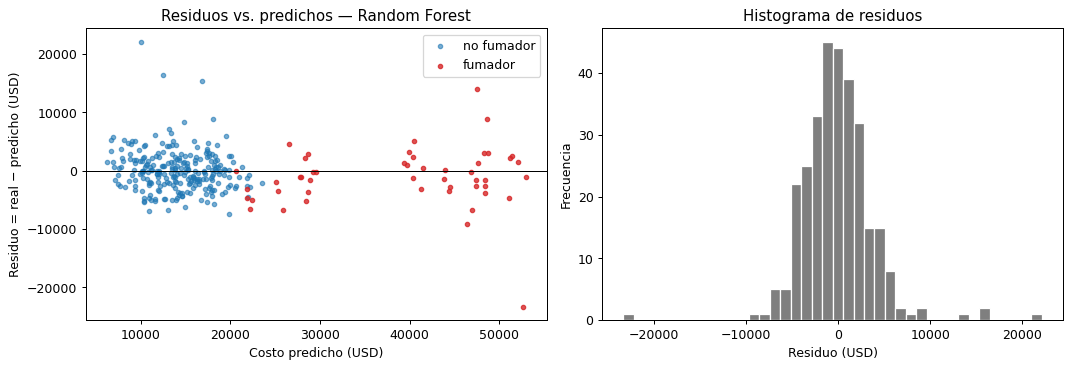

In [5]:
pred = ajustados[mejor].predict(X_test)
residuos = y_test - pred
es_fum = X_test['fumador'] == 'yes'
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].scatter(pred[~es_fum], residuos[~es_fum], s=12, alpha=0.6, label='no fumador')
ax[0].scatter(pred[es_fum], residuos[es_fum], s=12, alpha=0.8, color='tab:red', label='fumador')
ax[0].axhline(0, color='black', lw=0.8)
ax[0].set_xlabel('Costo predicho (USD)'); ax[0].set_ylabel('Residuo = real − predicho (USD)')
ax[0].set_title(f'Residuos vs. predichos — {mejor}'); ax[0].legend()
ax[1].hist(residuos, bins=40, color='tab:gray', edgecolor='white')
ax[1].set_xlabel('Residuo (USD)'); ax[1].set_ylabel('Frecuencia'); ax[1].set_title('Histograma de residuos')
plt.tight_layout(); plt.show()

tercil = pd.qcut(pred, 3, labels=['bajo', 'medio', 'alto'])
print("Residuo medio y desviación por tercil de predicción:")
print(pd.DataFrame({'res': residuos.values, 'tercil': tercil}).groupby('tercil', observed=True)['res'].agg(['mean', 'std', 'count']).round(0))
print(f"\nAsimetría de residuos: {residuos.skew():.2f} | residuos > 10,000 USD: {(residuos > 10000).sum()} de {len(residuos)}")

**Lectura de los residuos (Random Forest, antes).** El residuo medio pasa de +461 USD en el tercil bajo a −862 USD en el tercil alto: el bosque **sobrestima los costos bajos y subestima los altos**, el efecto típico de promediar hojas. La distribución tiene cola a la derecha (asimetría 0.56; 4 residuos > 10,000 USD): son asegurados con costos extra que ninguna variable observada explica. En la regresión lineal el patrón es más fuerte y se concentra en los **fumadores**, cuyo costo salta cuando el IMC ≥ 30, una interacción que un modelo aditivo no puede representar.